ANALISIS RÁPIDO DEL DÍA 20 DE NOVIEMBRE/ sabado (MIENTRAS SEGUIA ESCRAPEANDO)7

Visualización rápida de los datos

In [4]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("vuelos_limpio20.csv")
df

,Unnamed: 0,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,flight_Aircraft,Gate
0,0,20/11/2025 14-38-34,Ryanair,FR8215,London (STN),06:00,Ha salido,189.0,Boeing 737-800,Y
1,1,20/11/2025 14-38-34,Ryanair,FR2918,Brussels (BRU),06:05,Ha salido,189.0,Boeing 737-800,U
2,2,20/11/2025 14-38-34,easyJet Europe,EC7105,Geneva (GVA),06:10,Ha salido,156.0,Airbus A319,R
3,3,20/11/2025 14-38-34,Ryanair,FR3976,Dublin (DUB),06:15,Ha salido,197.0,Boeing 737 MAX 8,W
4,4,20/11/2025 14-38-34,easyJet Europe,EC7191,Glasgow (GLA),06:40,Ha salido,156.0,Airbus A319,R
...,...,...,...,...,...,...,...,...,...,...
125,126,20/11/2025 14-38-34,BUZZ,RR3035,Krakow (KRK),21:30,Programado,197.0,Boeing 737 MAX 8,R
126,127,20/11/2025 14-38-34,BUZZ,RR4084,Warsaw (WMI),21:30,Programado,189.0,Boeing 737-800,S
127,128,20/11/2025 14-38-34,Wizz Air Malta,W46020,Rome (FCO),21:35,Programado,230.0,Airbus A321,U
128,129,20/11/2025 14-38-34,Wizz Air,W64116,Belgrade (BEG),22:10,Programado,230.0,Airbus A321,W


In [8]:
df.isna().sum()[df.isna().sum() > 0] 

flight_capacity    1
flight_Aircraft    1
Gate               2
dtype: int64

In [1]:
df.groupby("Name_company")["flight_capacity"].mean()
# media de capacidad segun compañía

NameError: name 'df' is not defined

In [93]:
df[['Name_Destiny']].value_counts()


Name_Destiny          
Dublin (DUB)              4
Milan (MXP)               4
Budapest (BUD)            4
London (STN)              3
Rome (FCO)                3
                         ..
Chisinau (KIV)            1
Napoli (NAP)              1
Nice/Cote D'Azur (NCE)    1
Olbia (OLB)               1
Warsaw (WMI)              1
Name: count, Length: 81, dtype: int64

In [101]:
dest_counts = df["Name_Destiny"].value_counts()
top30 = dest_counts.head(30)
top30_sorted = top30.sort_values(ascending=True)

In [105]:
dest_counts = df["flight_Aircraft"].value_counts()
top40 = dest_counts.head(30)
top40_sorted = top40.sort_values(ascending=True)

In [127]:
# Crear una nueva columna solo con la hora (los dos primeros caracteres)
df['hour'] = df['Time_flight'].str[:2]

# Contar cuántas veces aparece cada hora
conteo_horas = df['hour'].value_counts()
ordenado_h = conteo_horas.sort_index()
# Mostrar resultados
print(ordenado_h)


hour
06     7
07     6
08     4
09    10
10    10
11     8
12     6
13    11
14     9
15     3
16     7
17     6
18     9
19    13
20    10
21     9
22     2
Name: count, dtype: int64


In [129]:
# Lista de aerolíneas que quieres considerar
lista = ["Ryanair", "BUZZ", "Lauda Europe"]

# Filtrar filas de esas aerolíneas
df_filtrado = df[df['Name_company'].isin(lista)]

# Crear columna con la hora (dos primeros caracteres de Time_flight)
df_filtrado.loc[:, 'hour'] = df_filtrado['Time_flight'].str[:2]

# Contar cuántas veces aparece cada hora
conteo_h = df_filtrado['hour'].value_counts()

# Ordenar por hora
ordenado_hfr = conteo_h.sort_index()

# Mostrar resultados
print(ordenado_hfr)


hour
06    5
07    3
08    4
09    3
10    4
11    5
12    2
13    5
14    1
15    2
16    4
17    3
18    5
19    5
20    2
21    4
Name: count, dtype: int64


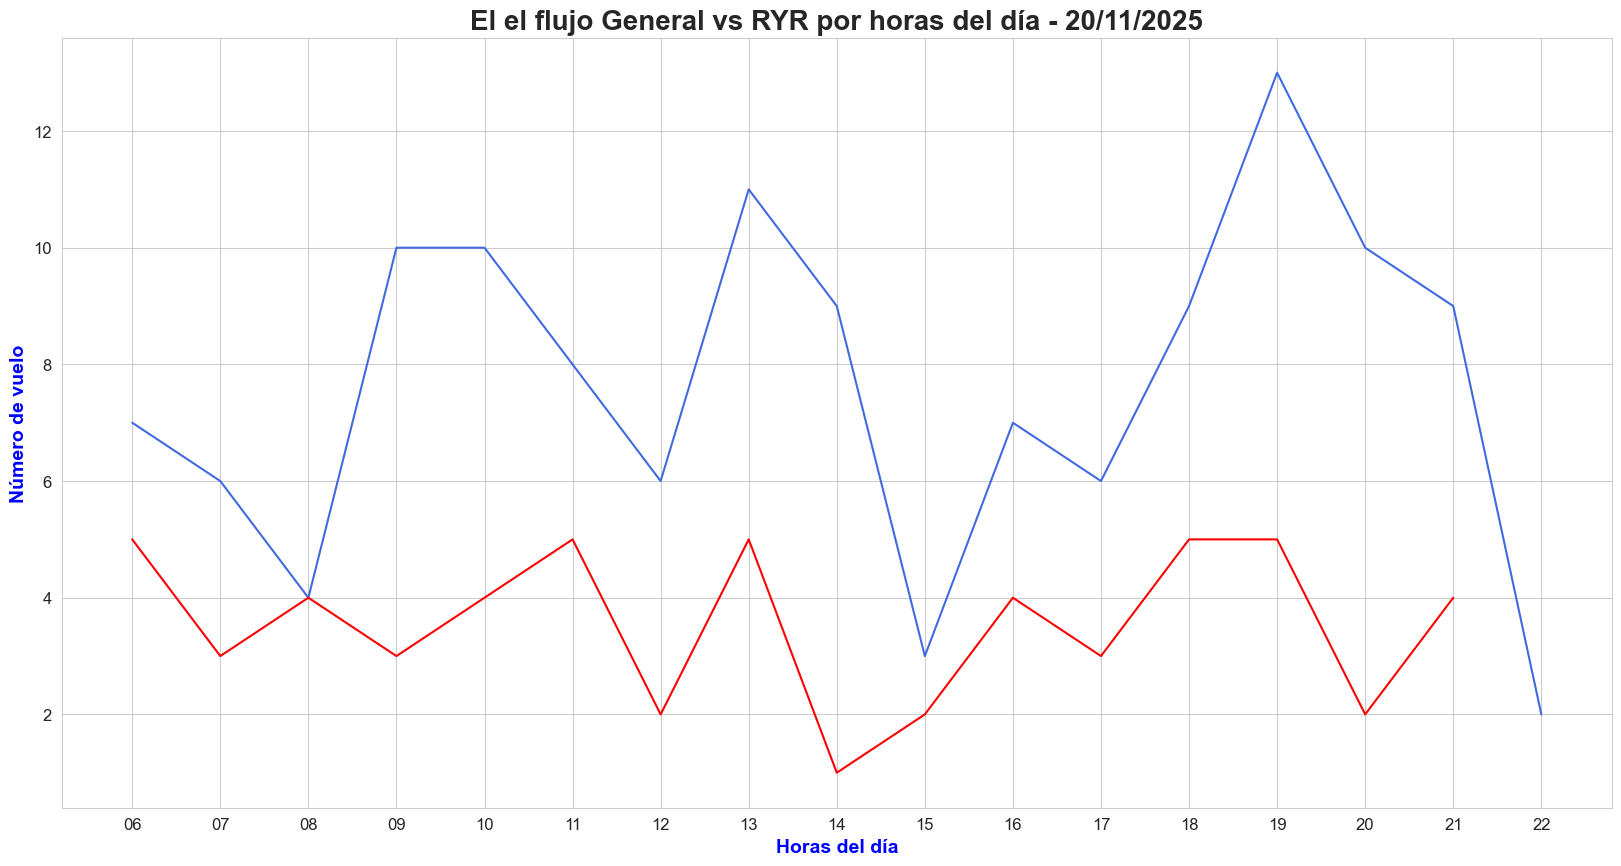

In [132]:
#ACTUALIZAR CUANDO LA COLUMNA SE ACTUALICE : 
plt.figure(figsize=(20,10))

sns.lineplot(x=ordenado_h.index, y=ordenado_h.values, color="royalblue")
sns.lineplot(x=ordenado_hfr.index, y=ordenado_hfr.values, color="red")

plt.title("El el flujo General vs RYR por horas del día - 20/11/2025", fontsize=20, weight='bold')
plt.xlabel("Horas del día", fontsize=14, weight='bold', color='blue')
plt.ylabel("Número de vuelo", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()


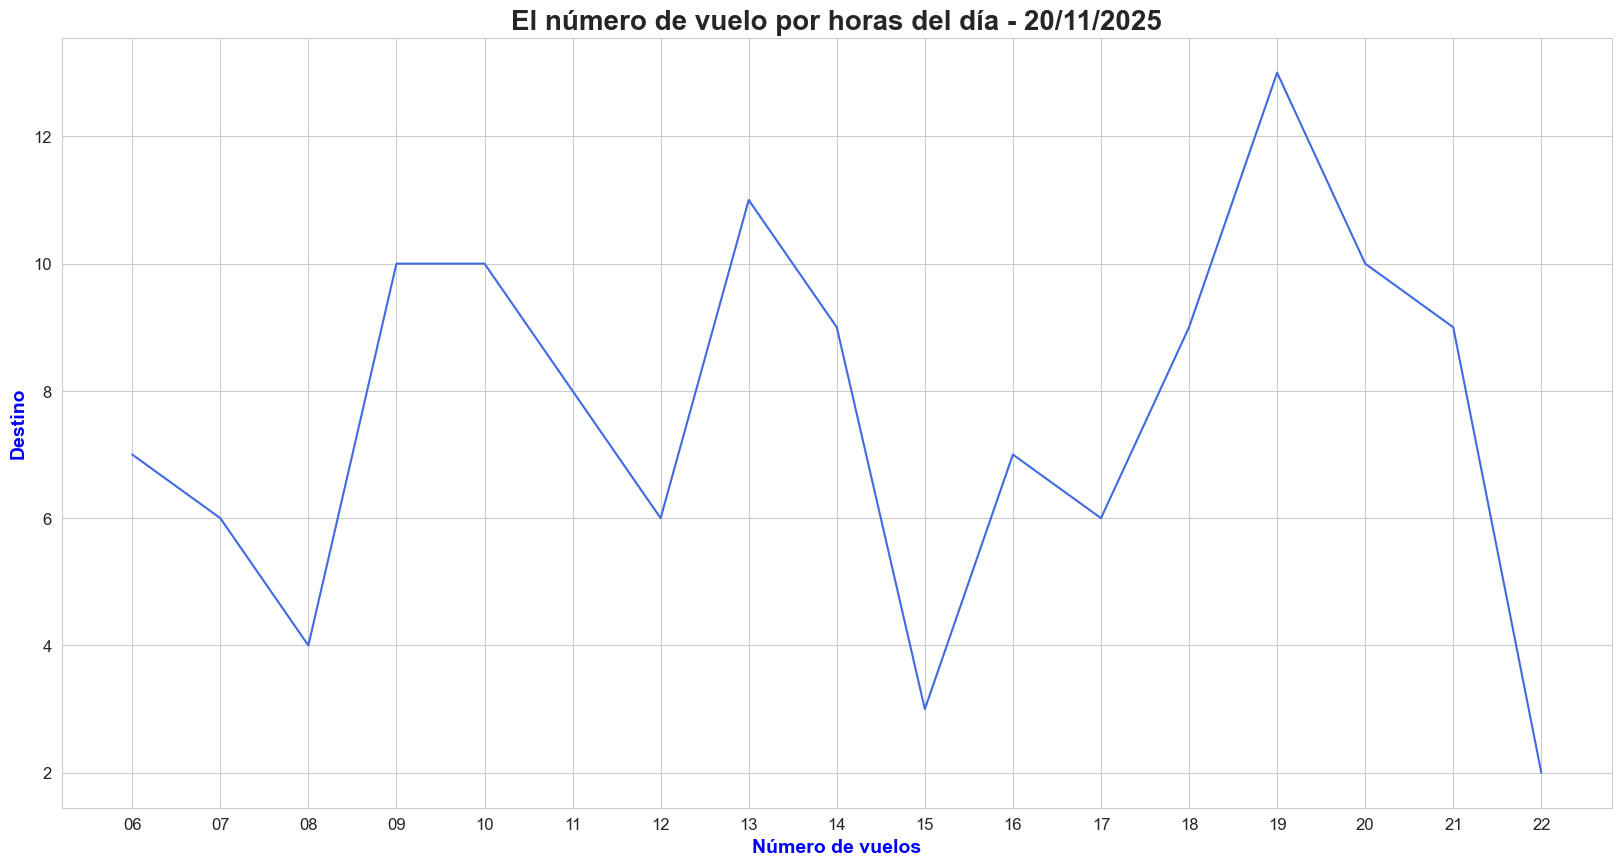

In [131]:
#ACTUALIZAR CUANDO LA COLUMNA SE ACTUALICE : 
plt.figure(figsize=(20,10))
sns.lineplot(x=ordenado_h.index, y=ordenado_h.values, color="royalblue")

plt.title("El número de vuelo por horas del día - 20/11/2025", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Destino", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()


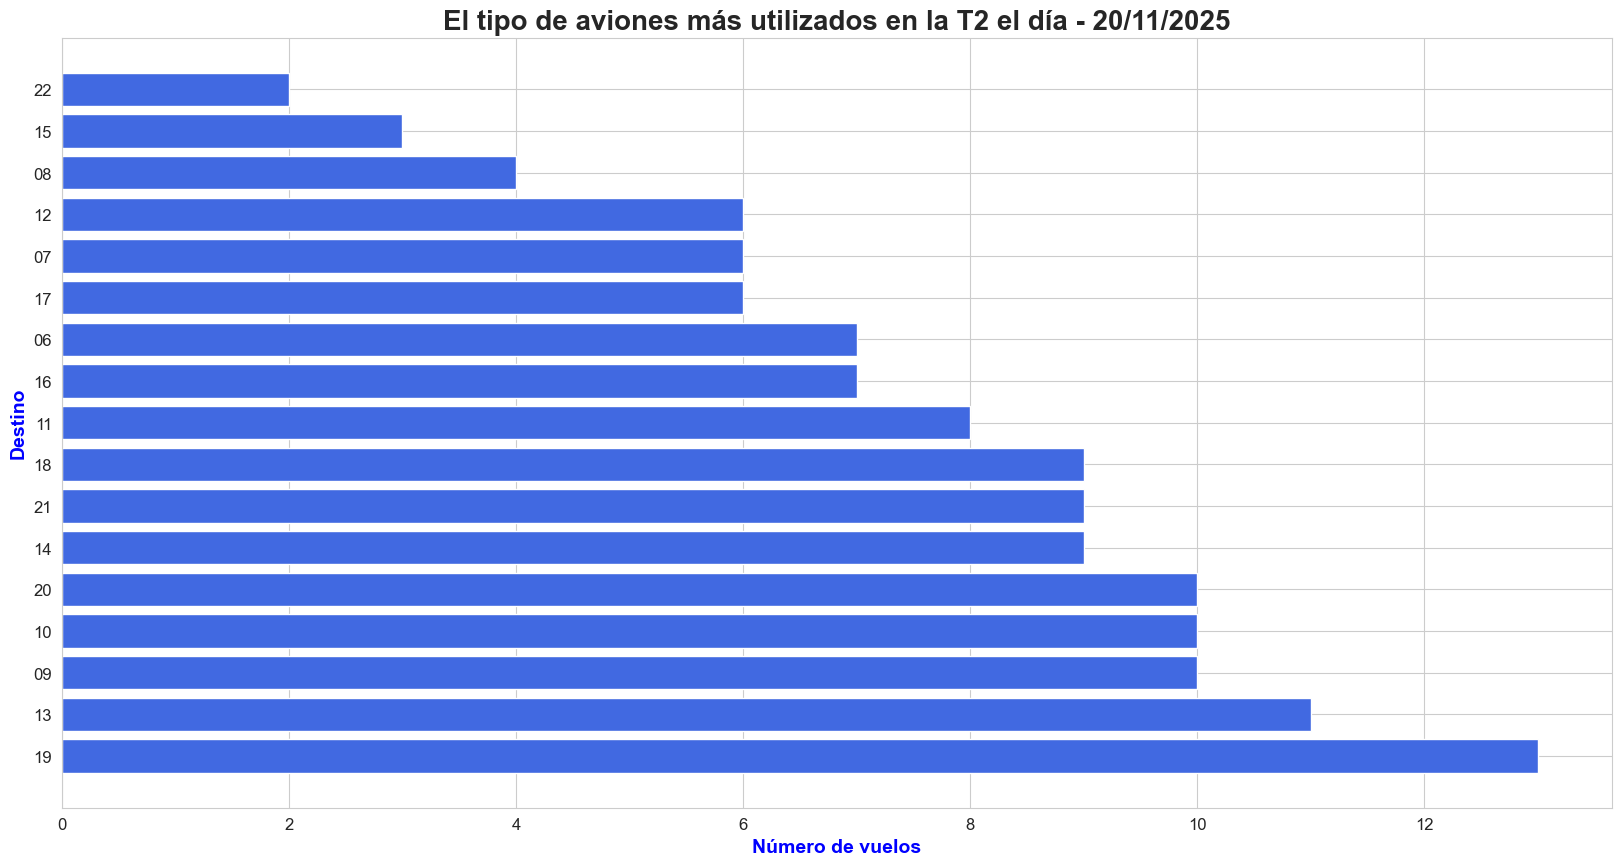

In [111]:
#ACTUALIZAR CUANDO LA COLUMNA SE ACTUALICE : 
plt.figure(figsize=(20,10))
plt.barh(conteo_horas.index, conteo_horas.values, color="royalblue")

plt.title("El tipo de aviones más utilizados en la T2 el día - 20/11/2025", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Destino", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()


In [108]:
dest_counts = df["flight_state"].value_counts()
top50_sorted = dest_counts.sort_values(ascending=True)

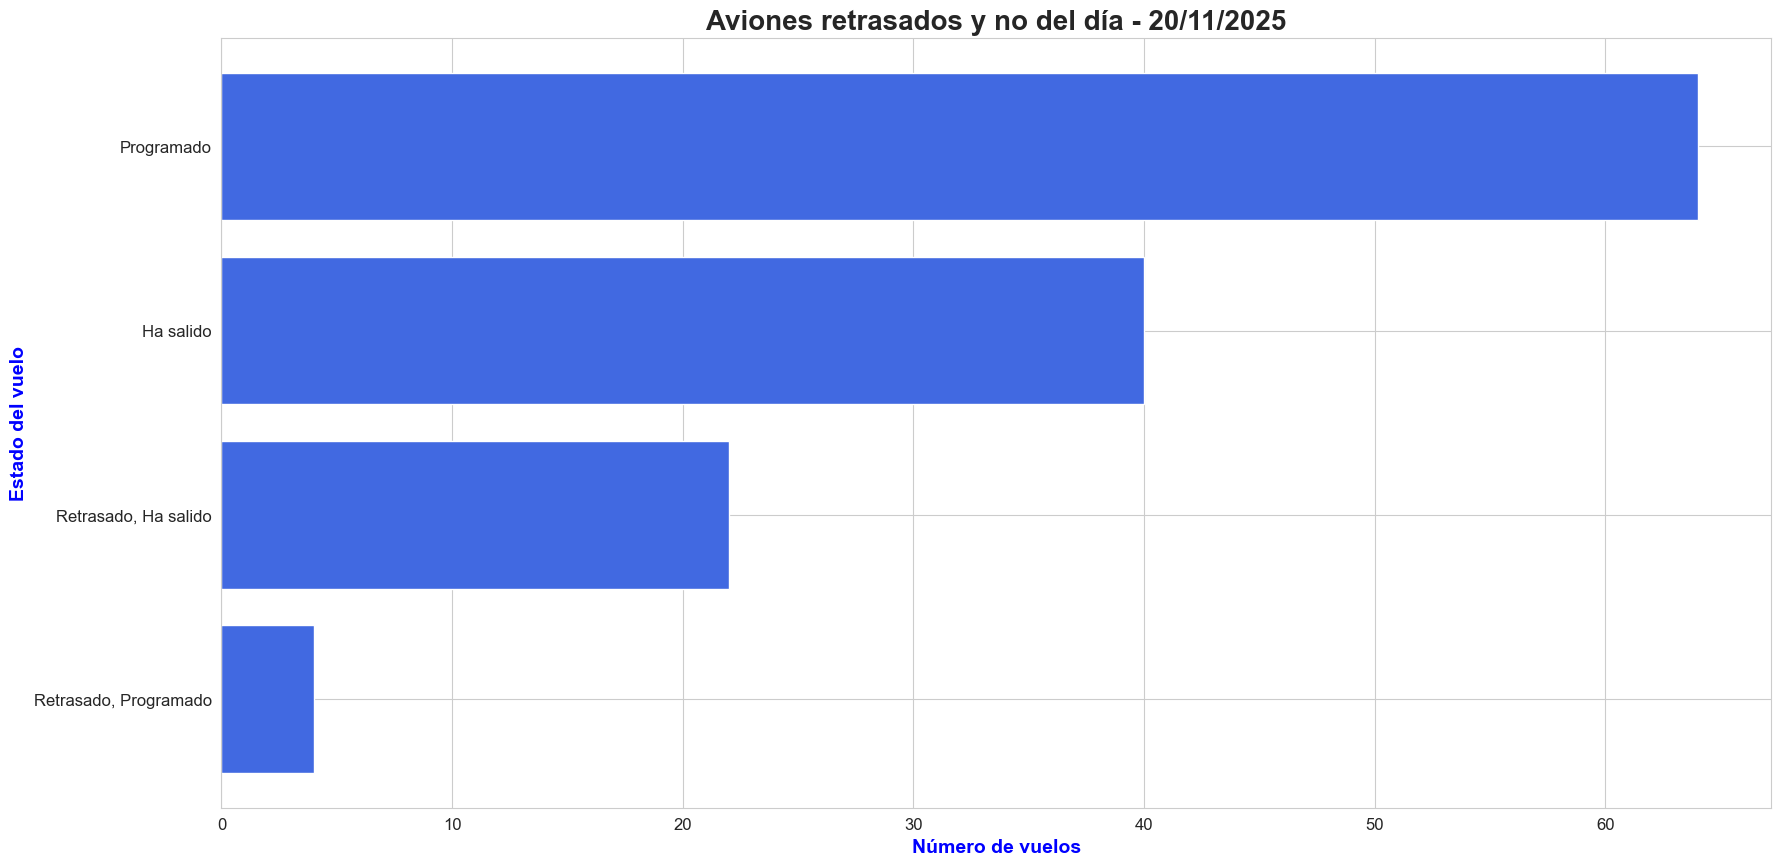

In [113]:
#ACTUALIZAR CUANDO LA COLUMNA SE ACTUALICE : 
plt.figure(figsize=(20,10))
plt.barh(top50_sorted.index, top50_sorted.values, color="royalblue")

plt.title("Aviones retrasados y no del día - 20/11/2025", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Estado del vuelo", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()


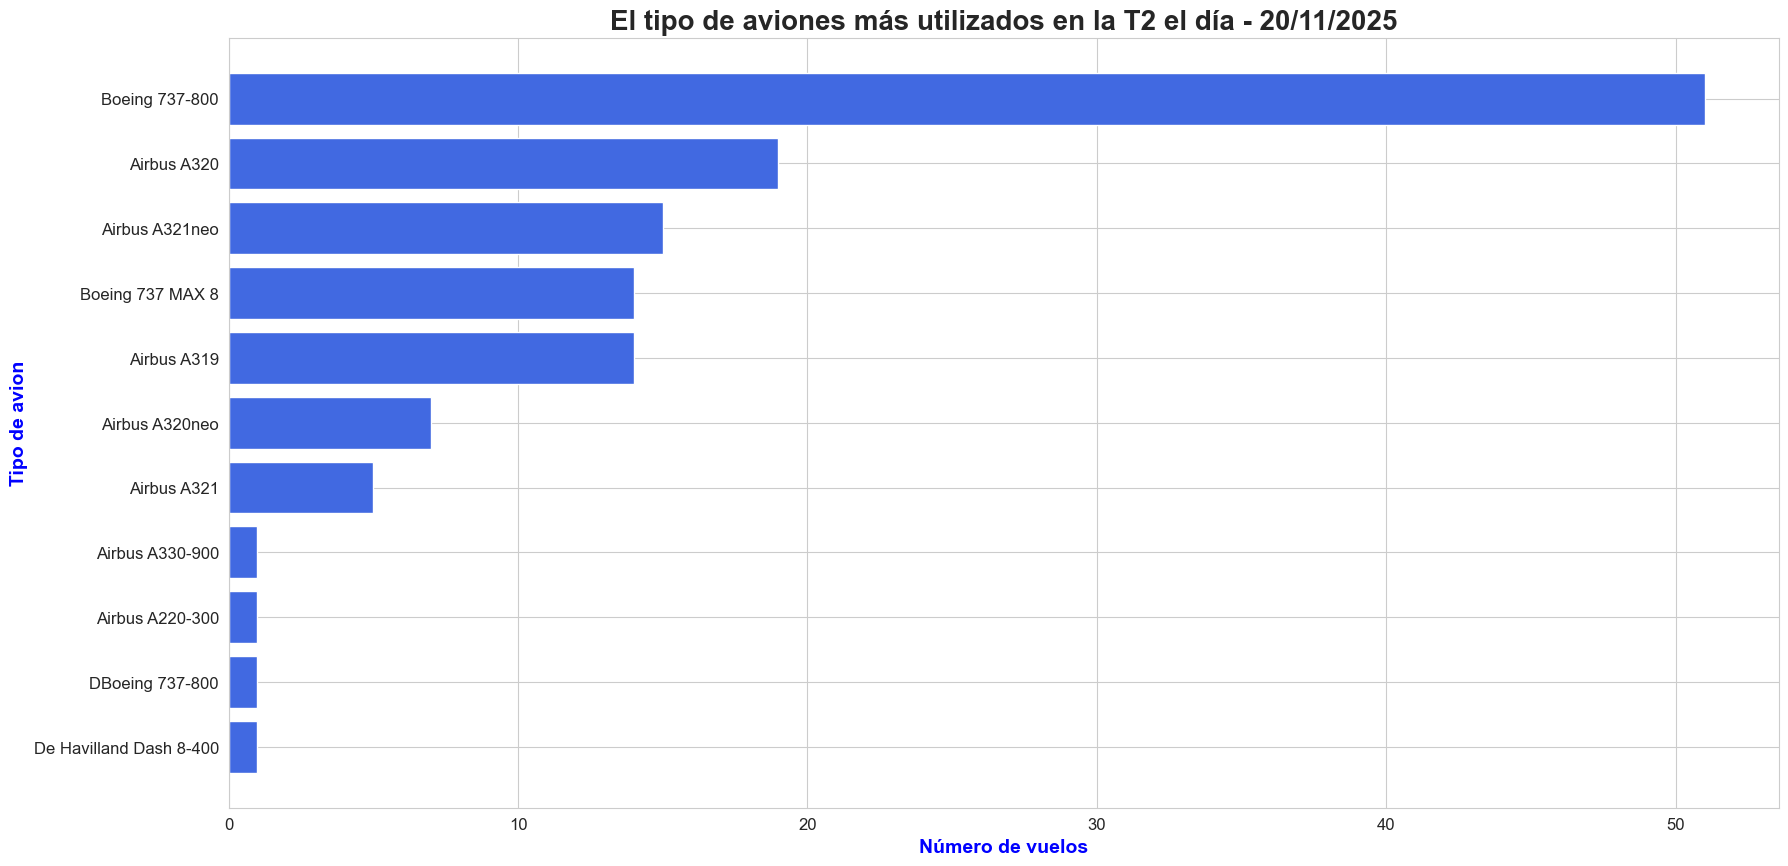

In [114]:
plt.figure(figsize=(20,10))
plt.barh(top40_sorted.index, top40_sorted.values, color="royalblue")

plt.title("El tipo de aviones más utilizados en la T2 el día - 20/11/2025", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Tipo de avion", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()


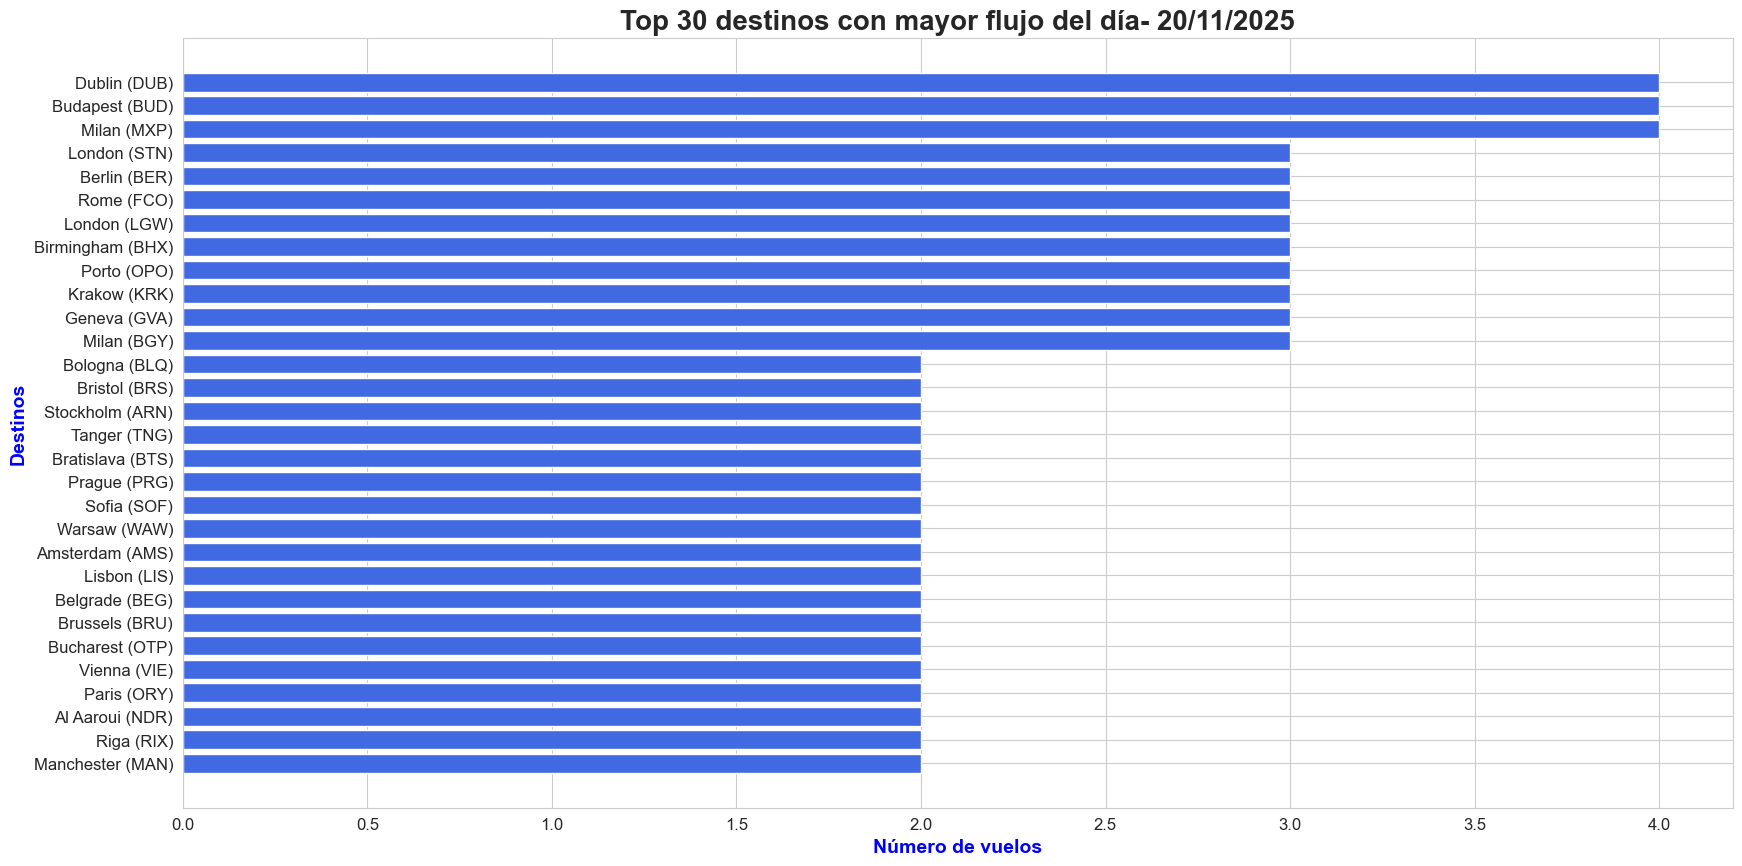

In [115]:
plt.figure(figsize=(20,10))
plt.barh(top30_sorted.index, top30_sorted.values, color="royalblue")

plt.title("Top 30 destinos con mayor flujo del día- 20/11/2025", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Destinos", fontsize=14, weight='bold', color='blue')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()


In [19]:
df_c =  df[['Name_company']].value_counts()
df_c

Name_company            
Ryanair                     48
easyJet Europe              15
Wizz Air                    11
Wizz Air Malta               9
BUZZ                         7
Transavia                    6
Volotea                      5
Easyjet                      5
Eurowings                    4
Norwegian Air Sweden AOC     3
Air Arabia Maroc             2
Aer Lingus                   2
Jet2                         2
Lauda Europe                 2
Luxair                       1
Kuwait Airways               1
Pegasus Airlines             1
SmartWings                   1
SunExpress                   1
Bluebird Airways             1
Azerbaijan Airlines          1
Air Serbia                   1
Air Baltic                   1
Name: count, dtype: int64

In [91]:
# LISTAS POR LAS CUALES AGRUPAR 
grupo = ["Ryanair", "BUZZ", "Lauda Europe"]
easy = ["easyJet Europe", "Easyjet"]
wizz = ["Wizz Air", "Wizz Air Malta"]
# Convertir Serie a DataFrame
df_tmp = df_c.reset_index() # RESETEAR INDICE 
df_tmp.columns = ["Name_company", "count"] # AÑADIR NOMBRE A COLUMNAS

# Crear una sola columna de agrupación
def asignar_grupo(x):
    if x in grupo: # SI X ESTA EN LA PRIMERA LISTA 
        return "Grupo_Ryanair" # LLAMARLO GRUPO RYANAIR 
    elif x in easy: # SI EL VALOR DE FILA ESTA EN EASY LLAMARLO GRUPO_EASYJET
        return "Grupo_Easyjet"
    elif x in wizz: # SI EL VALOR DE FILA ESTA EN EASY LLAMARLO 
        return "Grupo_WizzAir"
    else: # SINO RETORNA EL MISMO VALOR 
        return x

# CAMBIO DE NOMBRE DE COL Y NOMBRE DE VALORES IGUALES A LA LISTA AGRUPADAS 
df_tmp["company_grouped"] = df_tmp["Name_company"].apply(asignar_grupo) 

# AGRUPAMOS POR DOS COLUMNAS Y SUMAMOS LOS GRUPOS , RESETEAR INDICE 
df_final = df_tmp.groupby("company_grouped")["count"].sum().reset_index()

# TOTAL SUMA GUARDADA EN VARIABLE 
total_ryanair = df_final.loc[df_final["company_grouped"] == "Grupo_Ryanair", "count"].values[0]
total_easyjet = df_final.loc[df_final["company_grouped"] == "Grupo_Easyjet", "count"].values[0]
total_wizzair = df_final.loc[df_final["company_grouped"] == "Grupo_WizzAir", "count"].values[0]
# Añadir columna total_conjunto
def total_conjunto(x):
    if x == "Grupo_Ryanair":
        return total_ryanair
    elif x == "Grupo_Easyjet":
        return total_easyjet
    elif x == "Grupo_WizzAir":
        return total_wizzair
    else:
        return None
# LA NUEVA COL ES IGUAL A LA SUMA DEL GRUPO APLICAR FUNSION
df_final["total_conjunto"] = df_final["company_grouped"].apply(total_conjunto)
df_final = df_final.sort_values(by="count", ascending=True)
df_final

,company_grouped,count,total_conjunto
2,Air Baltic,1,NaN
3,Air Serbia,1,NaN
4,Azerbaijan Airlines,1,NaN
5,Bluebird Airways,1,NaN
16,SunExpress,1,NaN
15,SmartWings,1,NaN
14,Pegasus Airlines,1,NaN
11,Kuwait Airways,1,NaN
12,Luxair,1,NaN
0,Aer Lingus,2,NaN


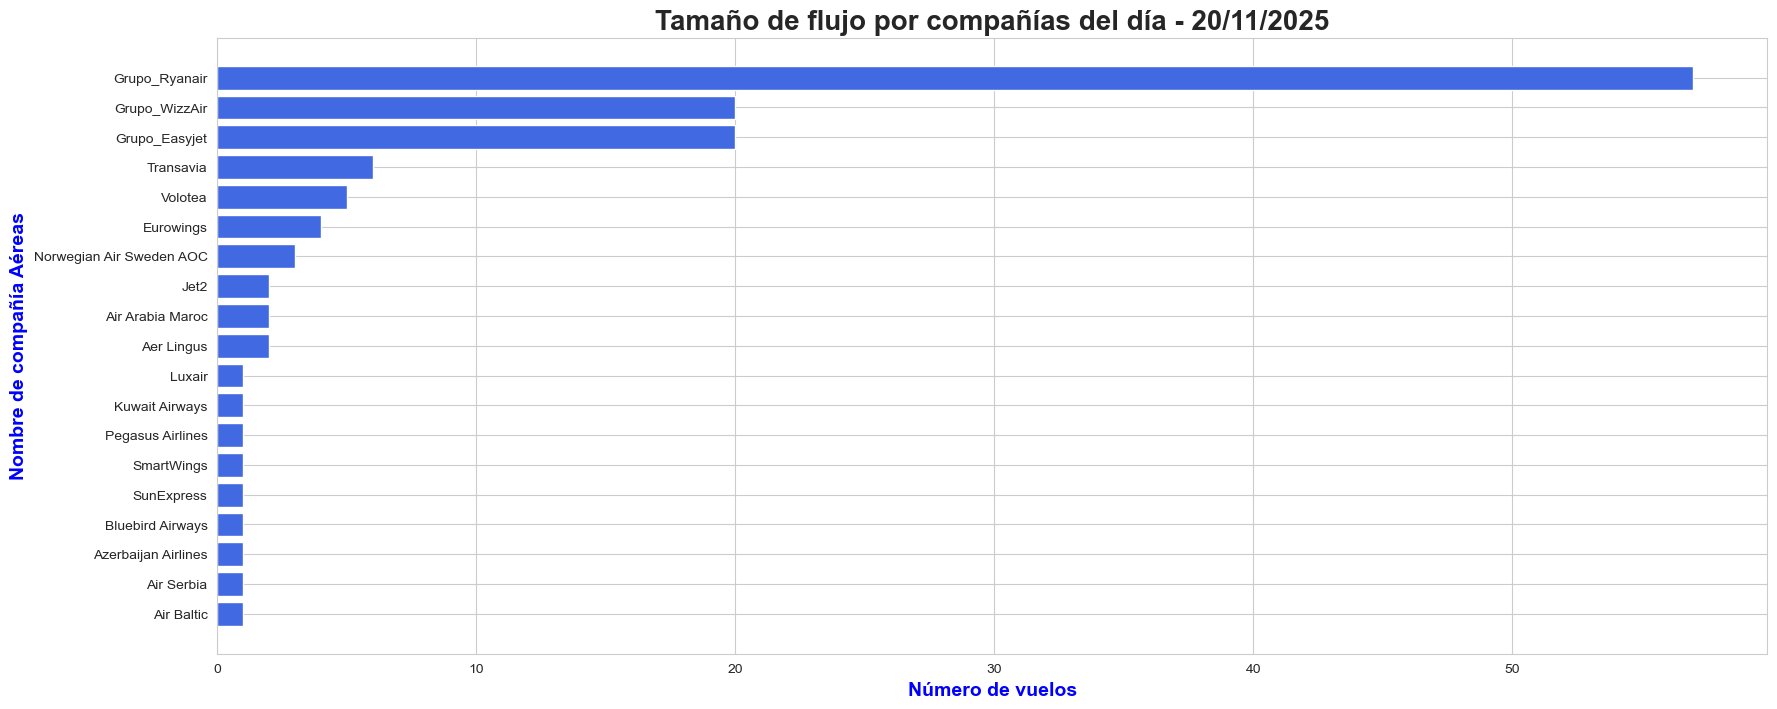

In [116]:
 #sns.set_style("whitegrid")  # Estilo de fondo
#sns.set_palette("tab10") 

plt.figure(figsize=(20,8))
plt.barh(df_final["company_grouped"], sorted(df_final["count"]), color="royalblue")

plt.title("Tamaño de flujo por compañías del día - 20/11/2025", fontsize=20, weight='bold')
plt.xlabel("Número de vuelos", fontsize=14, weight='bold', color='blue')
plt.ylabel("Nombre de compañía Aéreas", fontsize=14, weight='bold', color='blue')



plt.show()

In [54]:
# LISTAS POR LAS CUALES AGRUPAR 
grupo = ["Ryanair", "BUZZ", "Lauda Europe"]
easy = ["easyJet Europe", "Easyjet"]
wizz = ["Wizz Air", "Wizz Air Malta"]

df_tmp = df_c.reset_index()
df_tmp.columns = ["Name_company", "count"]

def asignar_grupo(x):
    if x in grupo:
        return "Grupo_Ryanair"
    elif x in easy:
        return "Grupo_Easyjet"
    elif x in wizz:
        return "Grupo_WizzAir"
    else:
        return "Otros"

df_tmp["company_grouped"] = df_tmp["Name_company"].apply(asignar_grupo)

df_final = df_tmp.groupby("company_grouped")["count"].sum().reset_index()

# Total global
total_global = df_final["count"].sum()

# Añadir columna porcentaje del conjunto
df_final["total_conjunto"] = df_final["count"] / total_global

df_final

,company_grouped,count,total_conjunto
0,Grupo_Easyjet,20,0.153846
1,Grupo_Ryanair,57,0.438462
2,Grupo_WizzAir,20,0.153846
3,Otros,33,0.253846


In [63]:
# LISTAS PARA AGRUPAR
grupo = ["Ryanair", "BUZZ", "Lauda Europe"]
easy = ["easyJet Europe", "Easyjet"]
wizz = ["Wizz Air", "Wizz Air Malta"]

# Convertir Serie a DataFrame
df_tmp = df_c.reset_index()
df_tmp.columns = ["Name_company", "count"]

# Función para asignar grupo
def asignar_grupo(x):
    if x in grupo:
        return "Grupo_Ryanair"
    elif x in easy:
        return "Grupo_Easyjet"
    elif x in wizz:
        return "Grupo_WizzAir"
    else:
        return x   # <-- el resto se queda tal cual

df_tmp["company_grouped"] = df_tmp["Name_company"].apply(asignar_grupo)

# Agrupar por compañía agrupada y sumar sus vuelos
df_final11 = df_tmp.groupby("company_grouped", as_index=False)["count"].sum()

# Calcular total general
total_general = df_final11["count"].sum()

# Agregar columna con porcentaje del total
df_final11["porcentaje_total"] = df_final11["count"] / total_general
df_final11

,company_grouped,count,porcentaje_total
0,Aer Lingus,2,0.015385
1,Air Arabia Maroc,2,0.015385
2,Air Baltic,1,0.007692
3,Air Serbia,1,0.007692
4,Azerbaijan Airlines,1,0.007692
5,Bluebird Airways,1,0.007692
6,Eurowings,4,0.030769
7,Grupo_Easyjet,20,0.153846
8,Grupo_Ryanair,57,0.438462
9,Grupo_WizzAir,20,0.153846


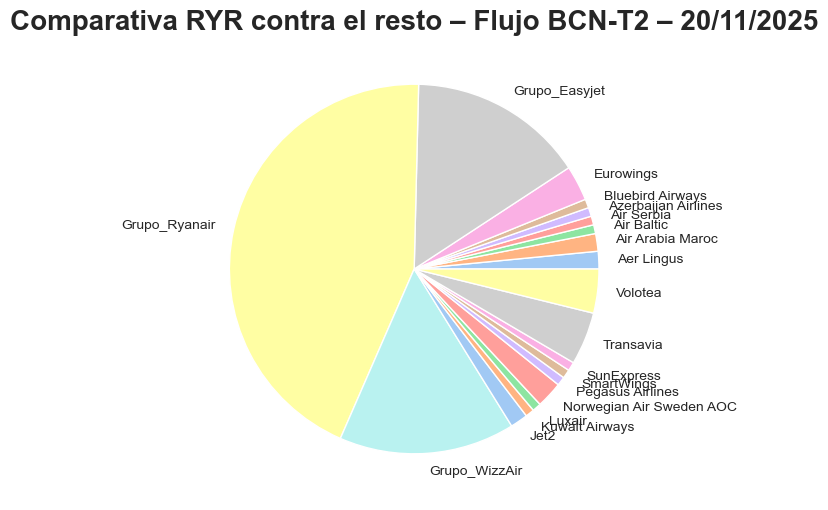

In [84]:
plt.figure(figsize=(12, 6))
colors = sns.color_palette("pastel")[0:len(df_final11)]
plt.pie(df_final11["porcentaje_total"],
        labels=df_final11["company_grouped"], 
        colors=colors)


plt.title("Comparativa RYR contra el resto – Flujo BCN-T2 – 20/11/2025", fontsize=20, weight='bold')
plt.show()


In [46]:
# LISTAS POR LAS CUALES AGRUPAR 
grupo = ["Ryanair", "BUZZ", "Lauda Europe"]
# Convertir Serie a DataFrame
df_tmp = df_c.reset_index() # RESETEAR INDICE 
df_tmp.columns = ["Name_company", "count"] # AÑADIR NOMBRE A COLUMNAS

# Crear una sola columna de agrupación
def asignar_grupo(x):
    if x in grupo: # SI X ESTA EN LA PRIMERA LISTA 
        return "Grupo_Ryanair" # LLAMARLO GRUPO RYANAIR 
    else: # SINO RETORNA EL MISMO VALOR 
        return "resto_grupos"

# CAMBIO DE NOMBRE DE COL Y NOMBRE DE VALORES IGUALES A LA LISTA AGRUPADAS 
df_tmp["company_grouped"] = df_tmp["Name_company"].apply(asignar_grupo) 

# AGRUPAMOS POR DOS COLUMNAS Y SUMAMOS LOS GRUPOS , RESETEAR INDICE 
df_final2 = df_tmp.groupby("company_grouped")["count"].sum().reset_index()

# TOTAL SUMA GUARDADA EN VARIABLE 
total_ryanair = df_final.loc[df_final["company_grouped"] == "Grupo_Ryanair", "count"].values[0]
resto_grupos = df_final.loc[df_final["company_grouped"] == "resto_grupos", "count"].values[0]

# Añadir columna total_conjunto
def total_conjunto(x):
    if x == "Grupo_Ryanair":
        percent = total_ryanair / (total_ryanair + resto_grupos) 
        return percent
    elif x == "resto_grupos":
        percent2 = resto_grupos / (total_ryanair + resto_grupos) 
        return percent2
    else:
        return None
# LA NUEVA COL ES IGUAL A LA SUMA DEL GRUPO APLICAR FUNSION
df_final2["porcentaje_total"] = df_final2["company_grouped"].apply(total_conjunto)

df_final2

,company_grouped,count,porcentaje_total
0,Grupo_Ryanair,57,0.438462
1,resto_grupos,73,0.561538


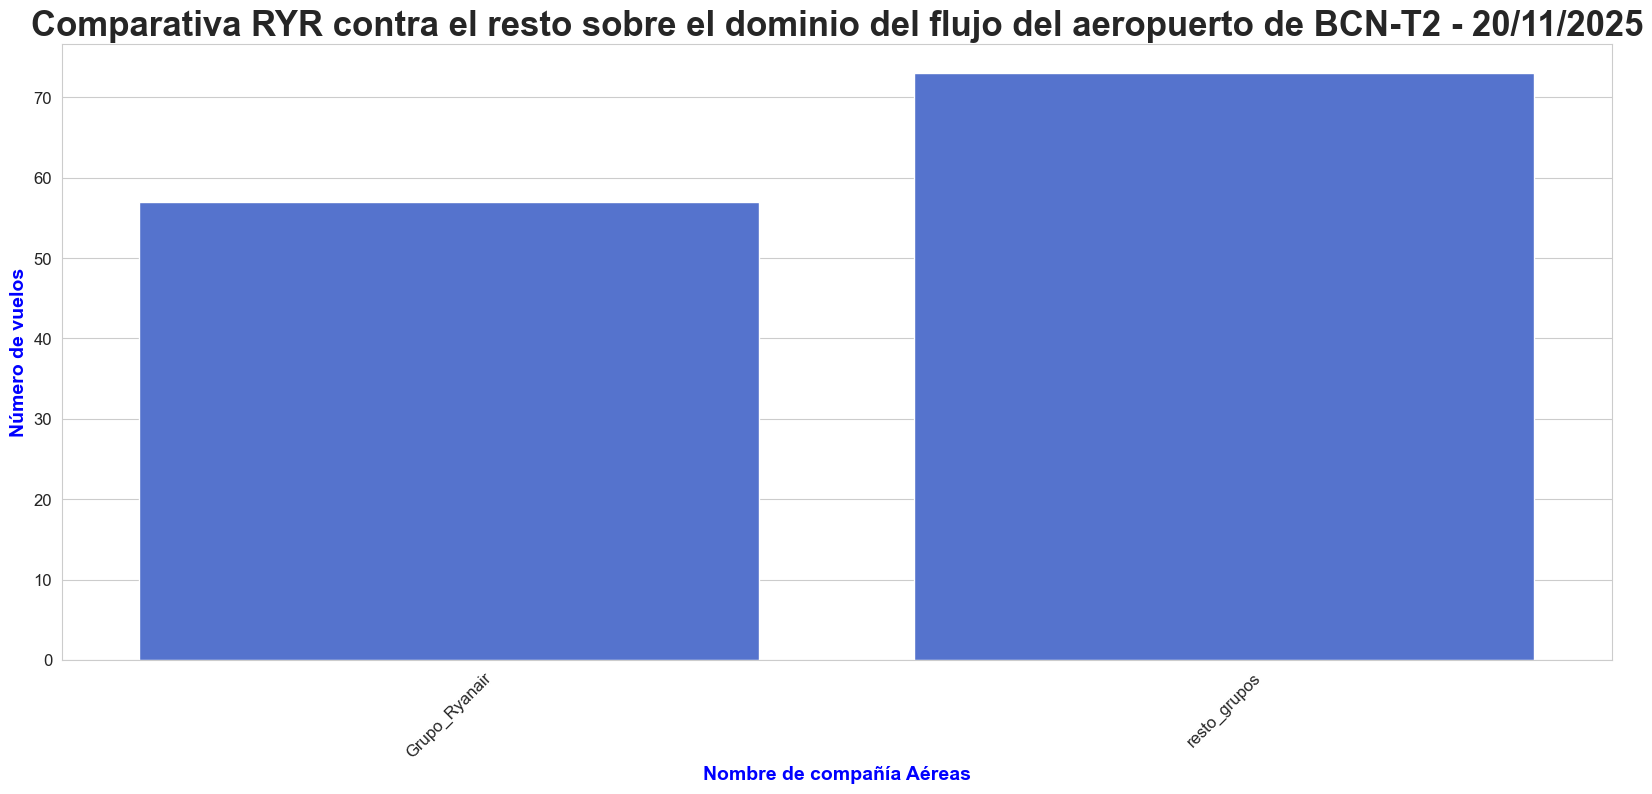

In [77]:
sns.set_style("whitegrid")  # Estilo de fondo
sns.set_palette("tab10") 

plt.figure(figsize=(20,8))
sns.barplot(x=df_final2["company_grouped"], y=df_final2["count"], color="royalblue")

plt.title("Comparativa RYR contra el resto sobre el dominio del flujo del aeropuerto de BCN-T2 - 20/11/2025", fontsize=25, weight='bold')
plt.xlabel("Nombre de compañía Aéreas", fontsize=14, weight='bold', color='blue')
plt.ylabel("Número de vuelos", fontsize=14, weight='bold', color='blue')

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()